# Chapter 5 &mdash; Ecosystem Modeling with Cellular Automata

Here a CA models a small **three-species ecosystem** &mdash;
plants, prey, and predators &mdash; on a torus. Simple local rules
for grazing, predation, death, and growth produce the classic
out-of-phase **predator/prey oscillations** of the Lotka&ndash;Volterra
equations, but as an *individual-based, spatial* model rather than
smooth differential equations.

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
from cadyn.ecosystem import Ecosystem

## Initialize and evolve

Cells are `EMPTY`, `PLANT`, `PREY`, or `PREDATOR`. We seed a world
with a modest prey and predator probability and let it run.

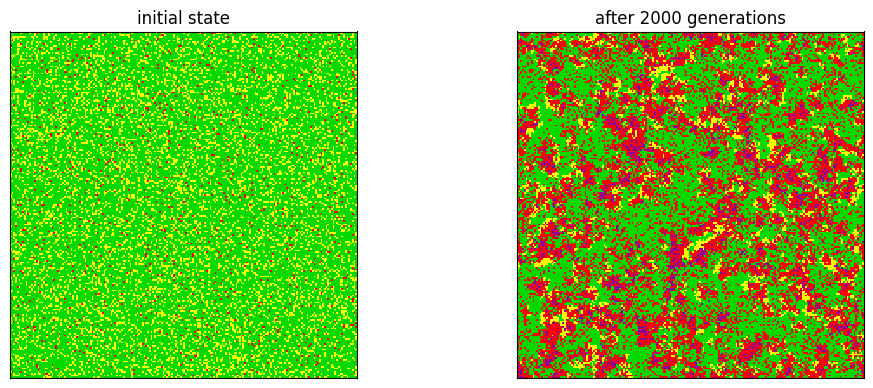

In [3]:
eco = Ecosystem(n=200, p_prey=0.212, p_pred=0.029,
                rng=np.random.default_rng(11))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
eco.show(ax=axes[0], title="initial state")
eco.run(2000)
eco.show(ax=axes[1], title="after 2000 generations")
plt.show()

## Population dynamics

Plotting the three populations over time reveals the tell-tale
signature: predators (red) and prey (yellow) oscillate **out of
phase**, damping toward a noisy equilibrium. Without predators the
prey would eat all the plants and then starve.

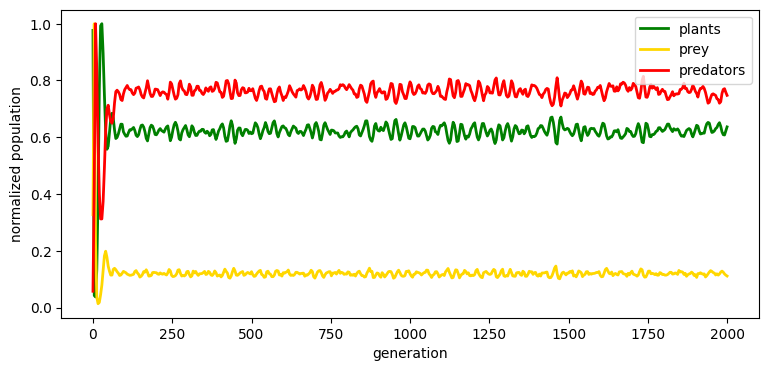

In [4]:
eco.plot_populations(sample_every=4)
plt.show()

## The phase portrait

Plot the three populations as one moving point in 3-D and the
oscillation becomes a **spiral** winding toward an interior
equilibrium &mdash; exactly the picture Poincar\u00e9 introduced for
differential equations.

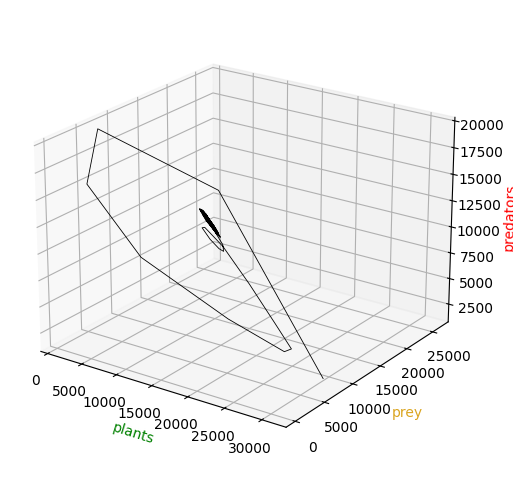

In [5]:
eco.plot_phase_portrait(sample_every=4)
plt.show()

## When does it collapse? A parameter sweep

Coexistence is not guaranteed. If predators are too feeble they die
out; too voracious and they strip the world in one overshoot. We can
map this directly by sweeping two predator parameters and recording
how often all species survive. (This is a smaller/faster sweep than
the book figure &mdash; raise the resolution if you have time.)

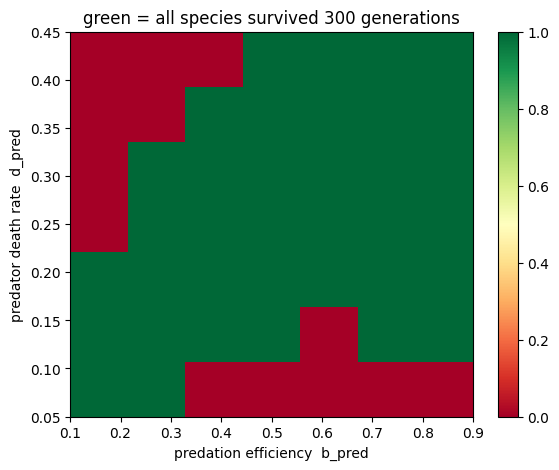

In [6]:
b_preds = np.linspace(0.1, 0.9, 7)
d_preds = np.linspace(0.05, 0.45, 7)
survival = np.zeros((len(d_preds), len(b_preds)))
for i, dp in enumerate(d_preds):
    for j, bp in enumerate(b_preds):
        e = Ecosystem(n=50, p_prey=0.212, p_pred=0.029,
                      b_pred=bp, d_pred=dp,
                      rng=np.random.default_rng(10*i + j))
        e.run_until(300)
        survival[i, j] = 0.0 if e.extinct() else 1.0

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(survival, origin="lower", cmap="RdYlGn",
               vmin=0, vmax=1, aspect="auto",
               extent=[b_preds[0], b_preds[-1],
                       d_preds[0], d_preds[-1]])
ax.set_xlabel("predation efficiency  b_pred")
ax.set_ylabel("predator death rate  d_pred")
ax.set_title("green = all species survived 300 generations")
fig.colorbar(im, ax=ax); plt.show()

## Your turn

1. Push the survival sweep to higher resolution and more trials per
   cell for a smoother phase diagram.
2. Find an "imprudent" parameter set that drives everything extinct,
   and plot the boom-and-bust transient with `eco.plot_populations()`.
3. Rotate the phase portrait: `ax = eco.plot_phase_portrait();
   ax.view_init(elev=30, azim=120)`.